In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)

In [27]:
try:
    df_pareto = pd.read_csv("pareto_front_results.csv")
    print("Pareto data loaded successfully.")
except FileNotFoundError:
    print("pareto_front_results.csv not found.")

try:
    df_base = pd.read_csv("baseline_results.csv")
    print("Baseline data loaded successfully.")
except FileNotFoundError:
    print("baseline_results.csv not found.")

Pareto data loaded successfully.
Baseline data loaded successfully.


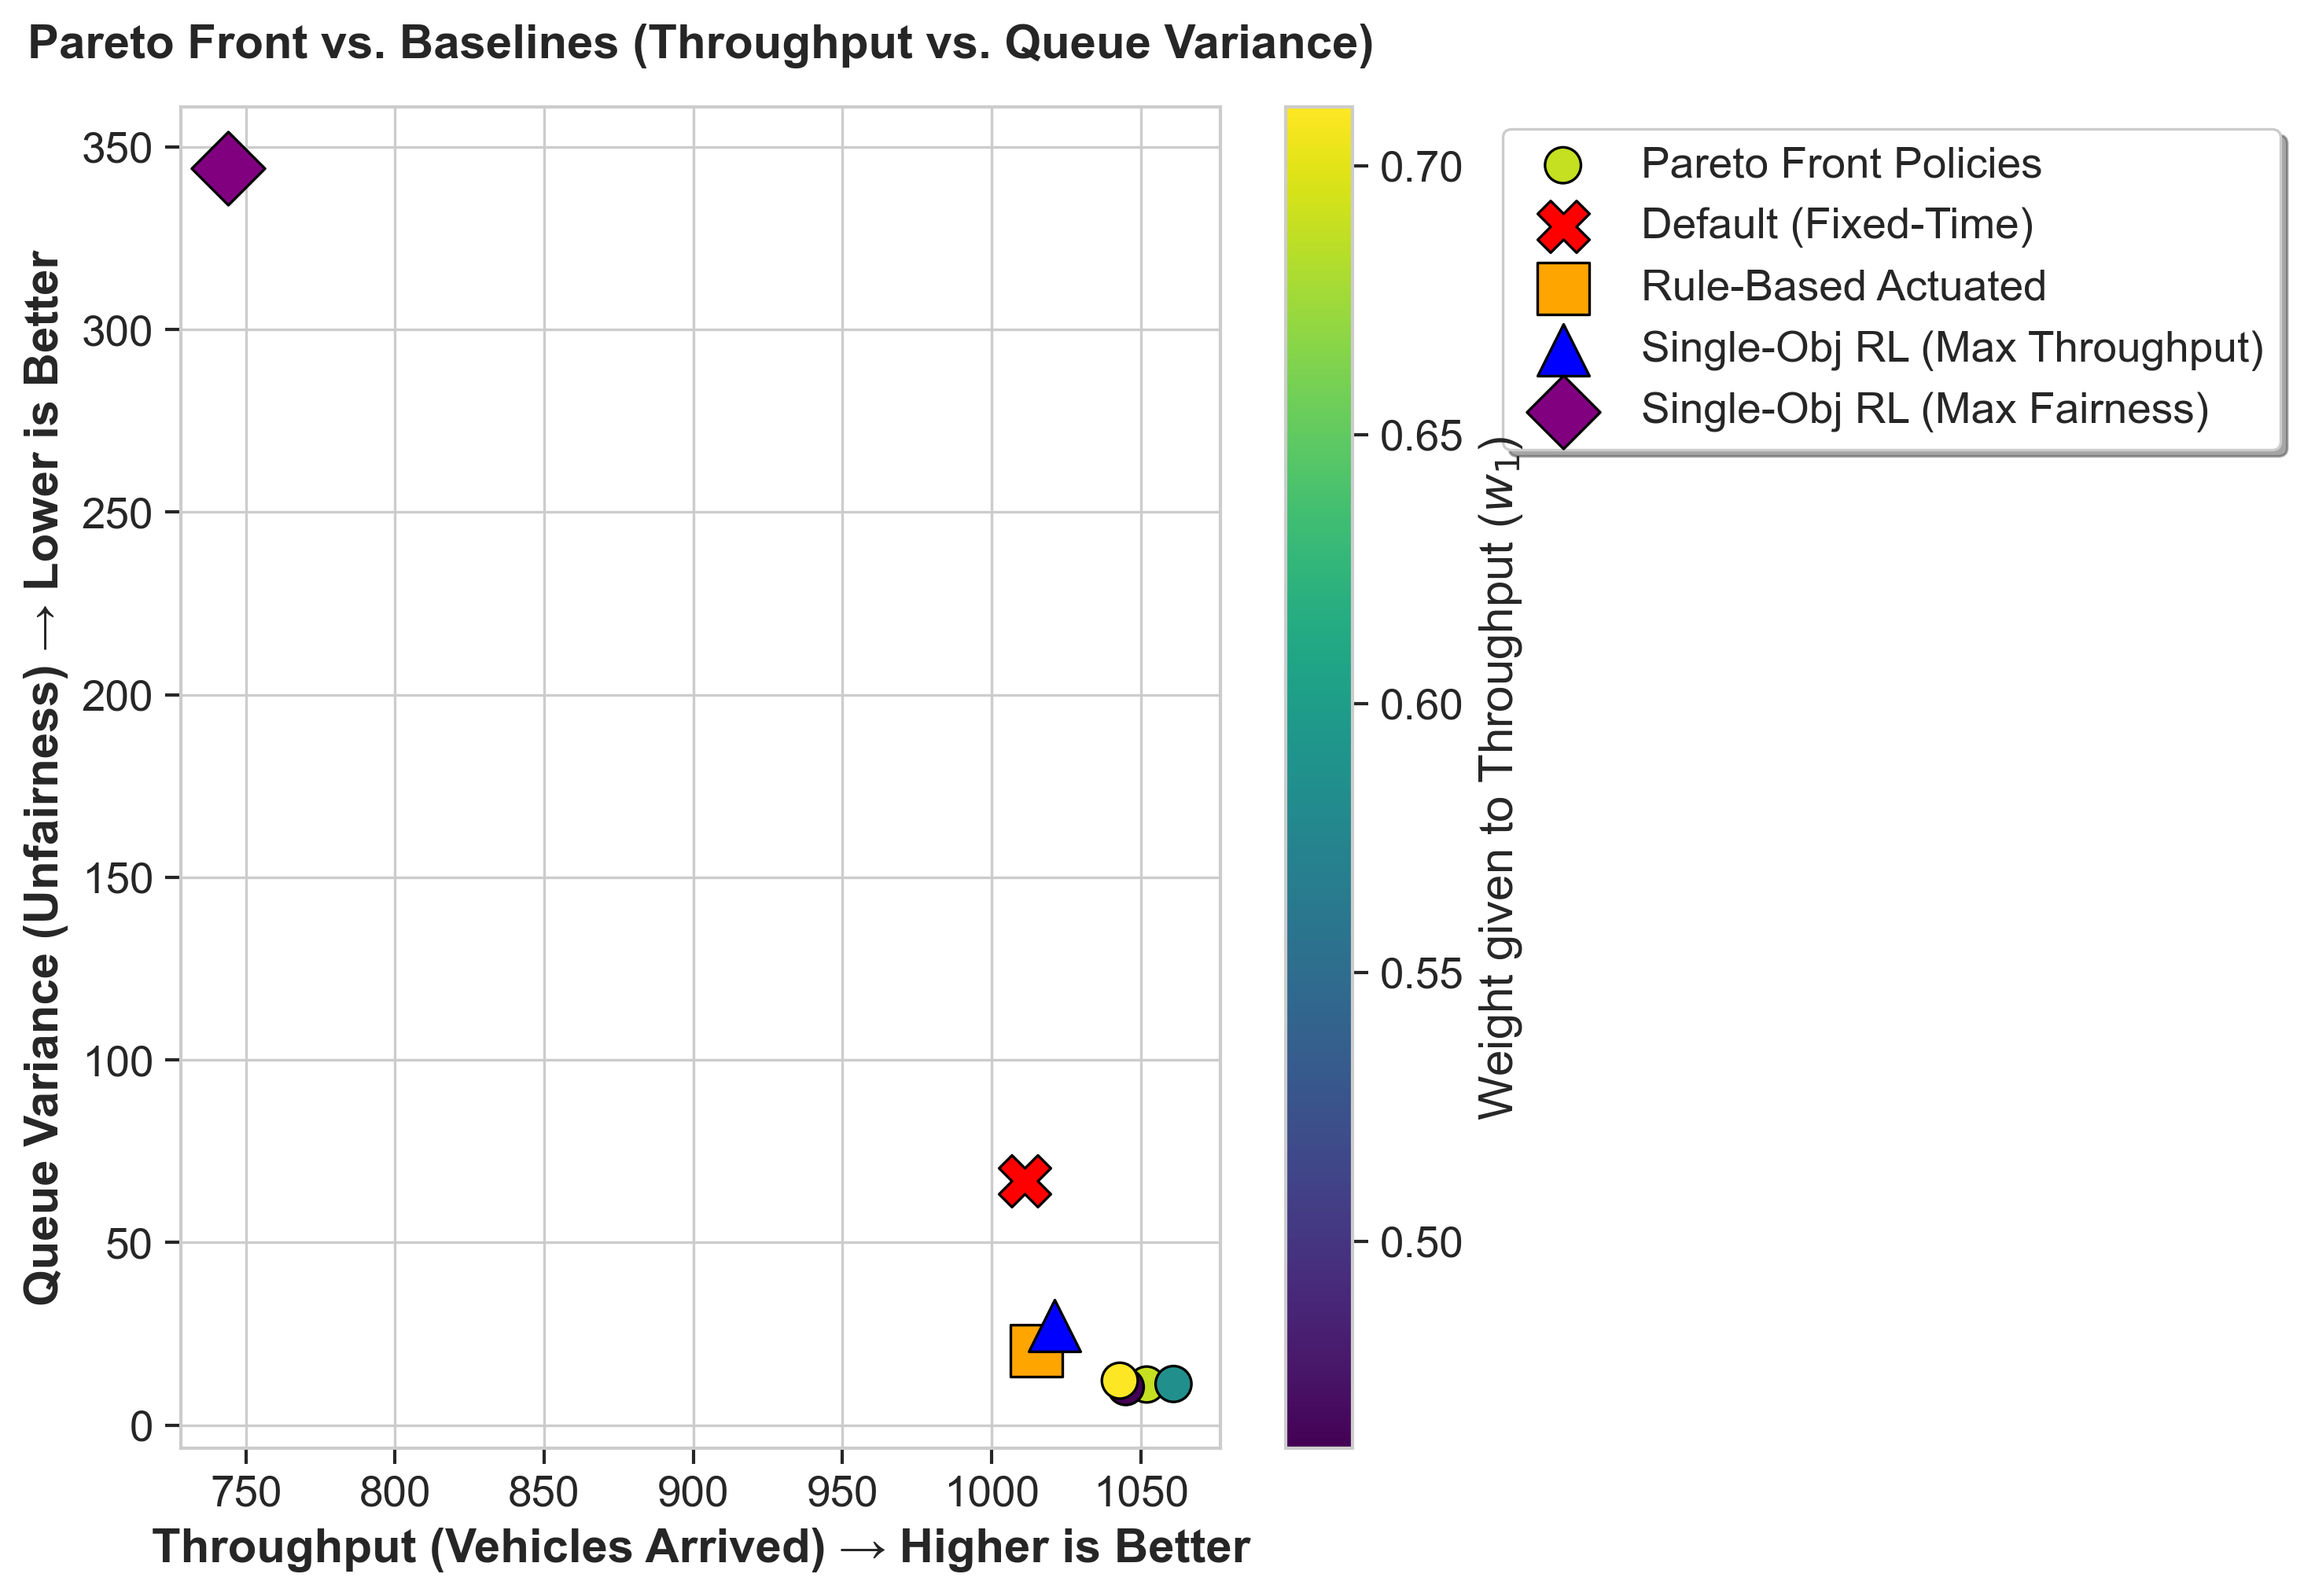

In [28]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

scatter = ax.scatter(df_pareto['throughput'], df_pareto['variance'], 
                     c=df_pareto['w_throughput'], cmap='viridis', 
                     s=120, edgecolors='black', label='Pareto Front Policies', zorder=3)

cbar = plt.colorbar(scatter)
cbar.set_label('Weight given to Throughput ($w_1$)')

markers = ['X', 's', '^', 'D']
colors = ['red', 'orange', 'blue', 'purple']

for i, row in df_base.iterrows():
    ax.scatter(row['Throughput'], row['Variance'], 
               color=colors[i], marker=markers[i], s=250, 
               edgecolors='black', label=row['Policy'], zorder=4)

ax.set_title("Pareto Front vs. Baselines (Throughput vs. Queue Variance)", weight='bold', pad=15)
ax.set_xlabel("Throughput (Vehicles Arrived) \u2192 Higher is Better", weight='bold')
ax.set_ylabel("Queue Variance (Unfairness) \u2192 Lower is Better", weight='bold')
ax.legend(bbox_to_anchor=(1.25, 1), loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig("pareto_vs_baselines_2d.png", bbox_inches='tight')
plt.show()

Selected Balanced AI Policy Weights:
T: 0.46, F: 0.12, S: 0.42


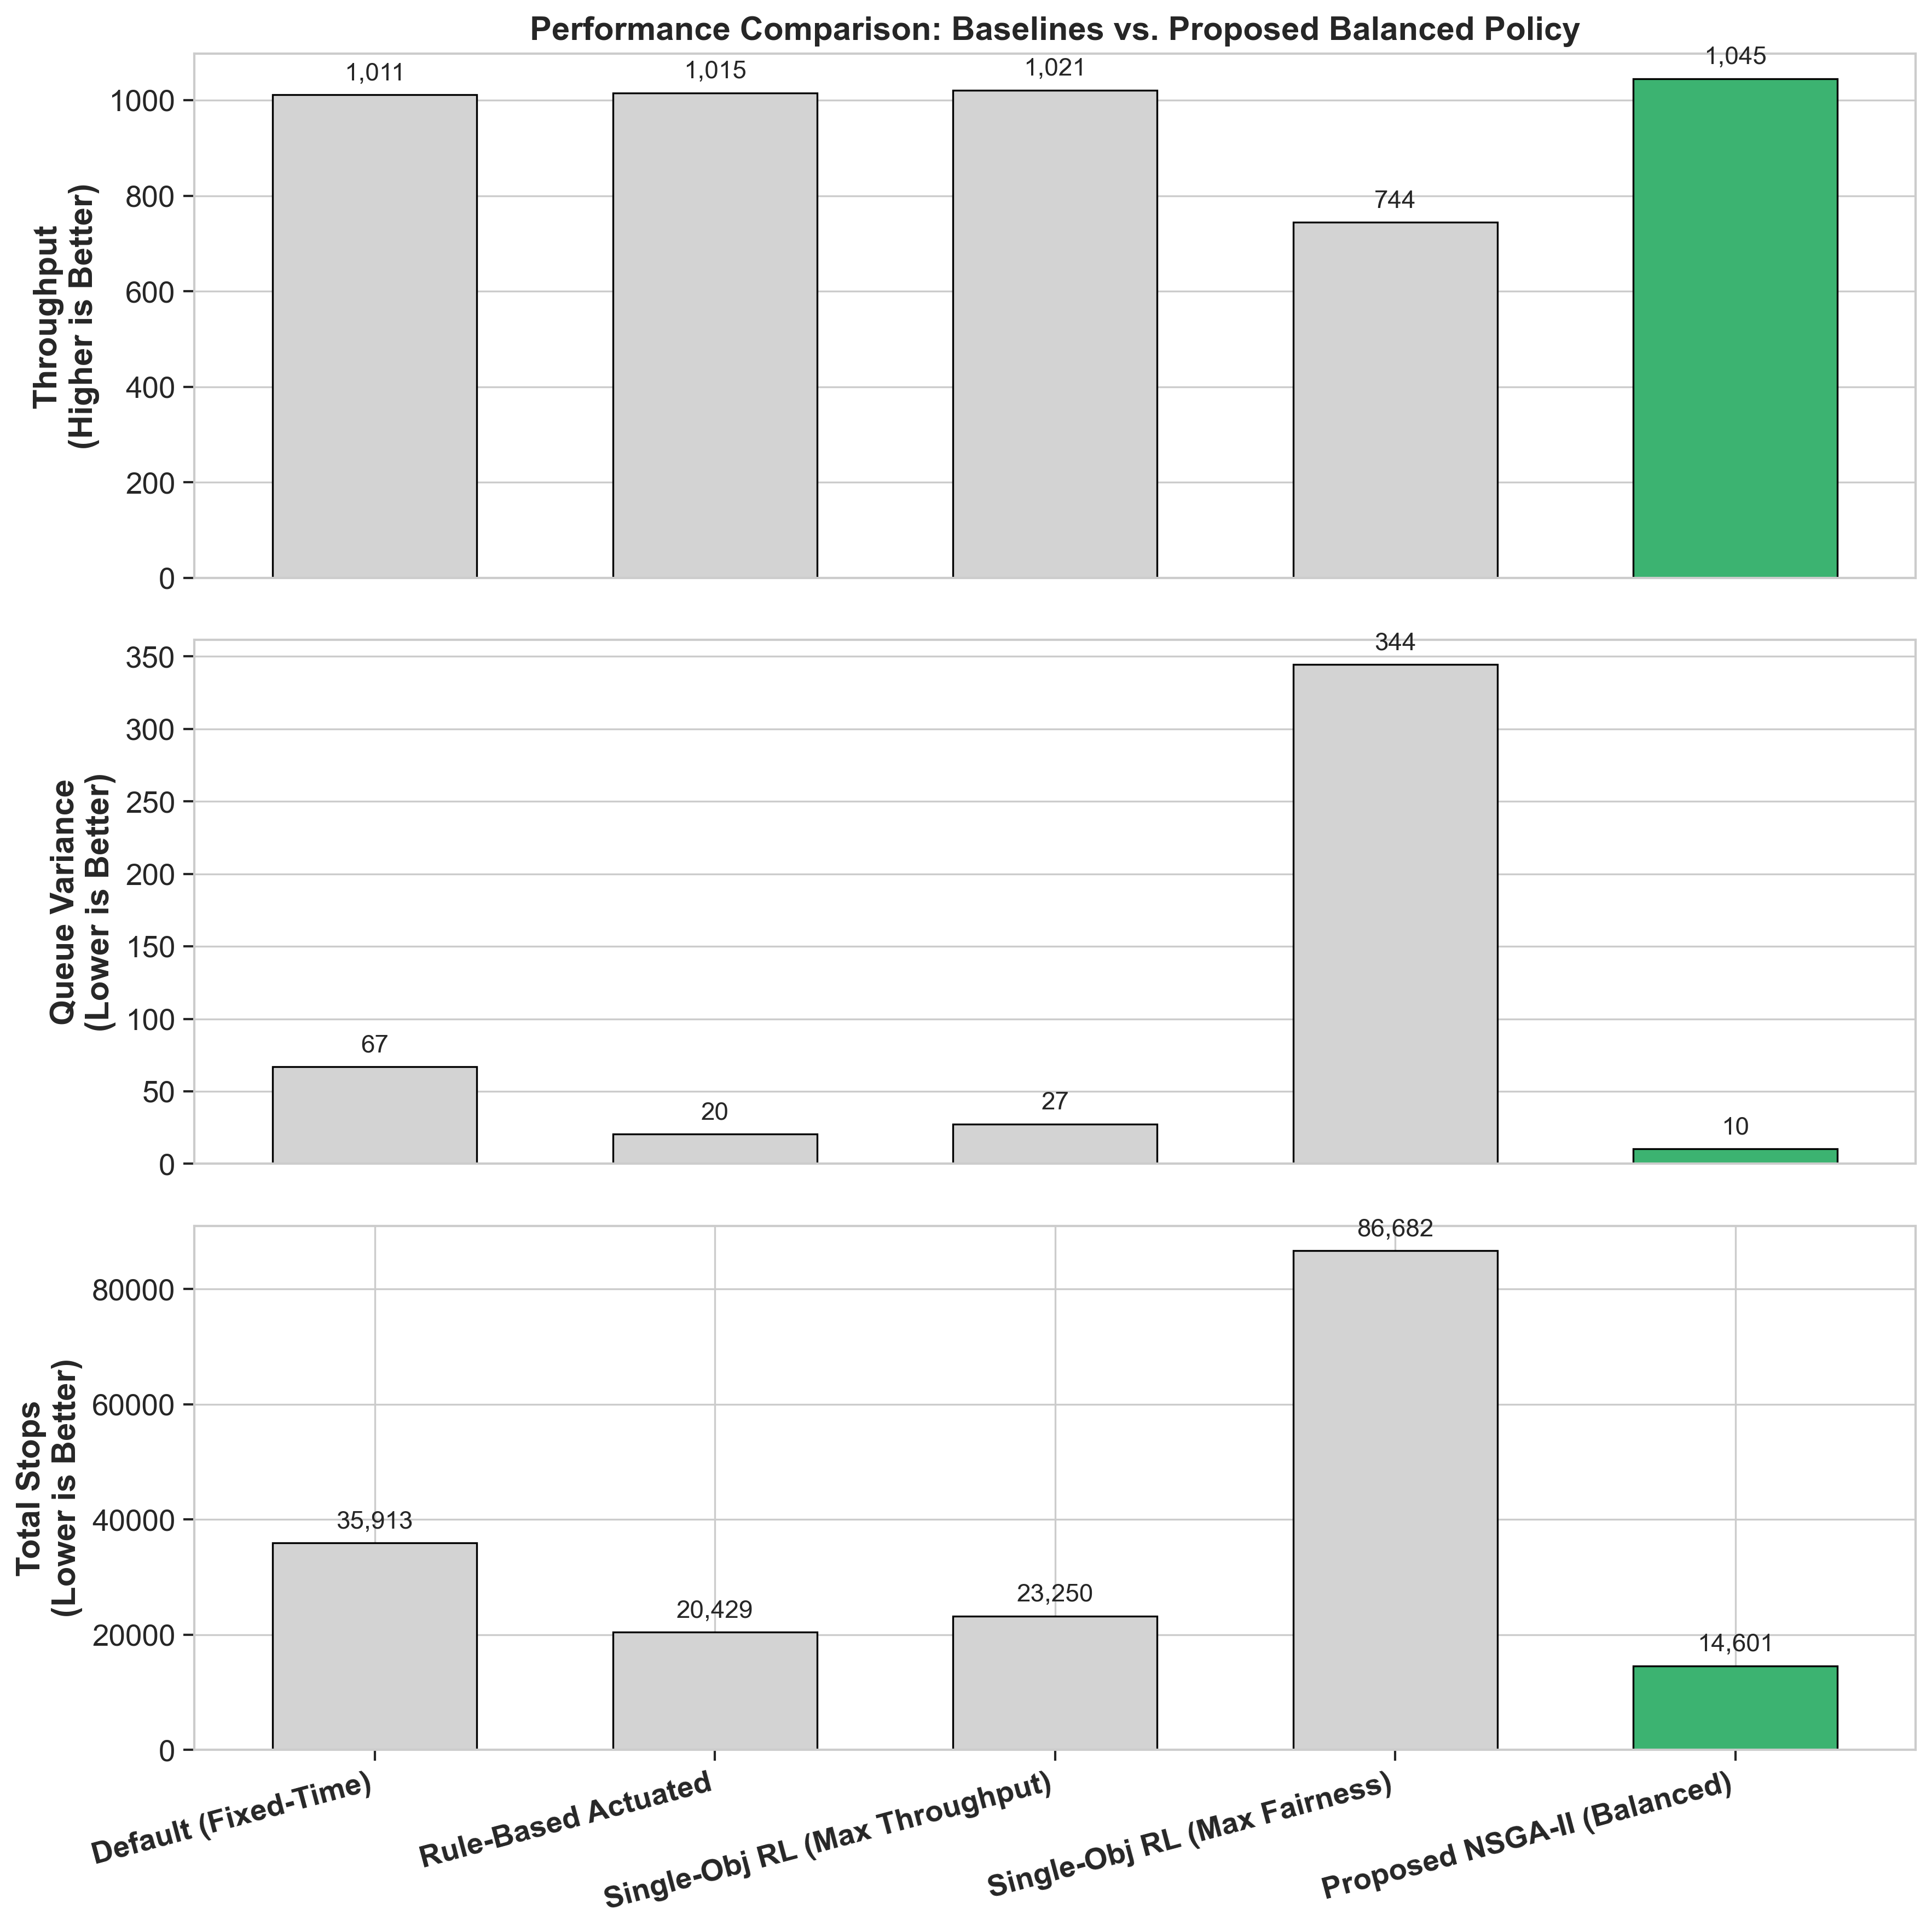

In [29]:
# most balanced policy in the Pareto Front (the one where the standard deviation of its weights is the lowest)
df_pareto['weight_std'] = df_pareto[['w_throughput', 'w_fairness', 'w_smoothness']].std(axis=1)
balanced_policy = df_pareto.loc[df_pareto['weight_std'].idxmin()]

print("Selected Balanced AI Policy Weights:")
print(f"T: {balanced_policy['w_throughput']:.2f}, F: {balanced_policy['w_fairness']:.2f}, S: {balanced_policy['w_smoothness']:.2f}")

policies = df_base['Policy'].tolist() + ['Proposed NSGA-II (Balanced)']
throughput = df_base['Throughput'].tolist() + [balanced_policy['throughput']]
variance = df_base['Variance'].tolist() + [balanced_policy['variance']]
stops = df_base['Stops'].tolist() + [balanced_policy['stops']]

x = np.arange(len(policies))
width = 0.6

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), dpi=300)
colors = ['lightgray', 'lightgray', 'lightgray', 'lightgray', 'mediumseagreen']
ax1.bar(x, throughput, width, color=colors, edgecolor='black')
ax1.set_ylabel('Throughput\n(Higher is Better)', weight='bold')
ax1.set_xticks([])
ax1.set_title('Performance Comparison: Baselines vs. Proposed Balanced Policy', weight='bold')

ax2.bar(x, variance, width, color=colors, edgecolor='black')
ax2.set_ylabel('Queue Variance\n(Lower is Better)', weight='bold')
ax2.set_xticks([]) 

ax3.bar(x, stops, width, color=colors, edgecolor='black')
ax3.set_ylabel('Total Stops\n(Lower is Better)', weight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(policies, rotation=15, ha="right", weight='bold')

for ax, metric in zip([ax1, ax2, ax3], [throughput, variance, stops]):
    for i, v in enumerate(metric):
        ax.text(i, v + (max(metric)*0.02), f"{v:,.0f}", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig("baselines_barchart_comparison.png", bbox_inches='tight')
plt.show()